In [1]:
import matplotlib.pyplot as plt
import numpy as np
import miepython

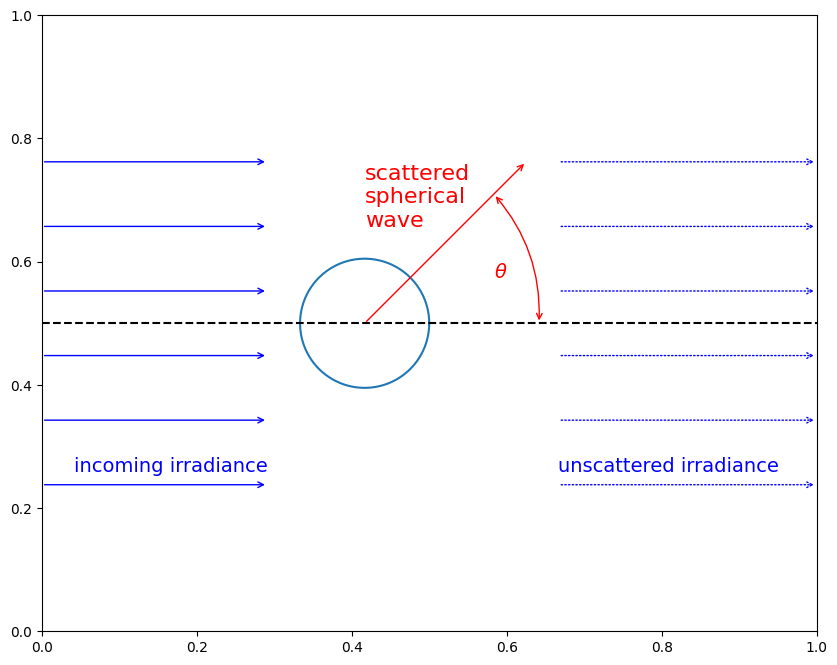

In [2]:
t = np.linspace(0,2*np.pi,100)
xx = np.cos(t)
yy = np.sin(t)
fig,ax=plt.subplots(figsize=(10,8))
plt.axes().set_aspect('equal')
plt.plot(xx,yy)
plt.plot([-5,7],[0,0],'--k')

plt.annotate('incoming irradiance', xy=(-4.5,-2.3),ha='left',color='blue',fontsize=14)
for i in range(6):
    y0 = i -2.5
    plt.annotate('',xy=(-1.5,y0),xytext=(-5,y0),arrowprops=dict(arrowstyle="->",color='blue'))

plt.annotate('unscattered irradiance', xy=(3,-2.3),ha='left',color='blue',fontsize=14)
for i in range(6):
    y0 = i -2.5
    plt.annotate('',xy=(7,y0),xytext=(3,y0),arrowprops=dict(arrowstyle="->",color='blue',ls=':'))

plt.annotate('scattered\nspherical\nwave', xy=(0,1.5),ha='left',color='red',fontsize=16)
plt.annotate('',xy=(2.5,2.5),xytext=(0,0),arrowprops=dict(arrowstyle="->",color='red'))
plt.annotate(r'$\theta$',xy=(2,0.7),color='red',fontsize=14)
plt.annotate('',xy=(2,2),xytext=(2.7,0),arrowprops=dict(connectionstyle="arc3,rad=0.2", arrowstyle="<->",color='red'))

plt.xlim(-5,7)
plt.ylim(-3,3)
plt.axis('off')
plt.show()

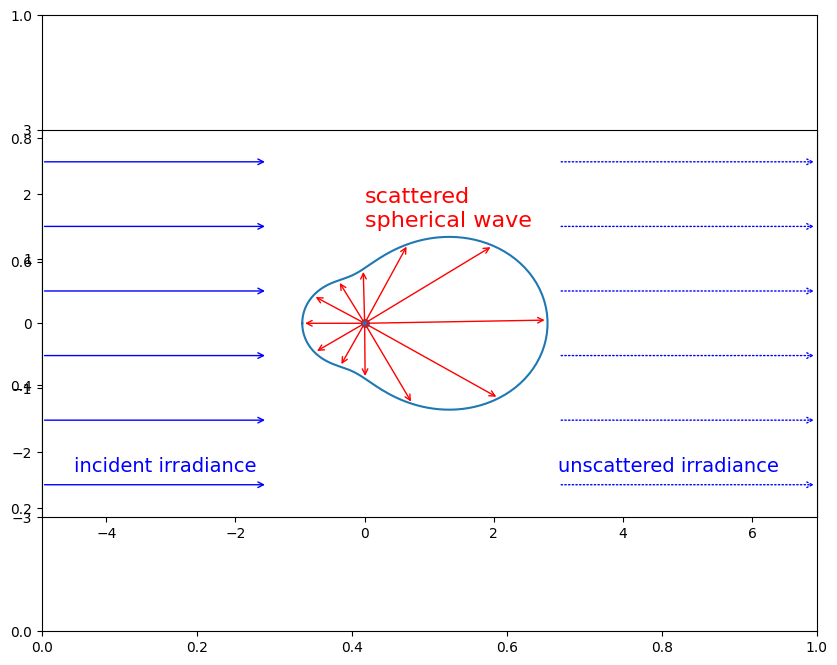

In [3]:
fig,ax=plt.subplots(figsize=(10,8))
plt.axes().set_aspect('equal')
plt.scatter([0],[0],s=30)

m = 1.5
x = np.pi/3
theta = np.linspace(-180,180,180)
theta_r = np.radians(theta)

mu = np.cos(theta_r)
scat = 15 * miepython.i_unpolarized(m,x,mu)

plt.plot(scat*np.cos(theta/180*np.pi),scat*np.sin(theta/180*np.pi))
for i in range(12):
    ii = i*15
    xx = scat[ii]*np.cos(theta_r[ii])
    yy = scat[ii]*np.sin(theta_r[ii])
#    print(xx,yy)
    plt.annotate('',xy=(xx,yy),xytext=(0,0),arrowprops=dict(arrowstyle="->",color='red'))


plt.annotate('incident irradiance', xy=(-4.5,-2.3),ha='left',color='blue',fontsize=14)
for i in range(6):
    y0 = i -2.5
    plt.annotate('',xy=(-1.5,y0),xytext=(-5,y0),arrowprops=dict(arrowstyle="->",color='blue'))

plt.annotate('unscattered irradiance', xy=(3,-2.3),ha='left',color='blue',fontsize=14)
for i in range(6):
    y0 = i -2.5
    plt.annotate('',xy=(7,y0),xytext=(3,y0),arrowprops=dict(arrowstyle="->",color='blue',ls=':'))

plt.annotate('scattered\nspherical wave', xy=(0,1.5),ha='left',color='red',fontsize=16)

plt.xlim(-5,7)
plt.ylim(-3,3)
#plt.axis('off')
plt.show()

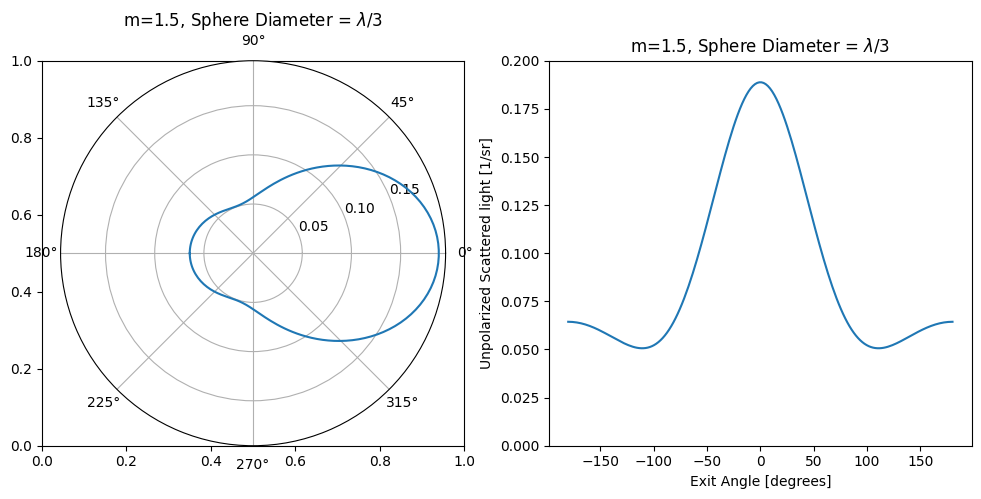

In [4]:
"""Unpolarized Scattering Function"""

m = 1.5
x = np.pi/3
theta = np.linspace(-180,180,180)
mu = np.cos(theta/180*np.pi)
scat = miepython.i_unpolarized(m,x,mu)

fig,ax = plt.subplots(1,2,figsize=(12,5))
ax=plt.subplot(121, projection='polar')
ax.plot(theta/180*np.pi,scat)
ax.set_rticks([0.05, 0.1,0.15])
ax.set_title("m=1.5, Sphere Diameter = $\lambda$/3")

plt.subplot(122)
plt.plot(theta,scat)
plt.xlabel('Exit Angle [degrees]')
plt.ylabel('Unpolarized Scattered light [1/sr]')
plt.title('m=1.5, Sphere Diameter = $\lambda$/3')
plt.ylim(0.00,0.2)

plt.show()

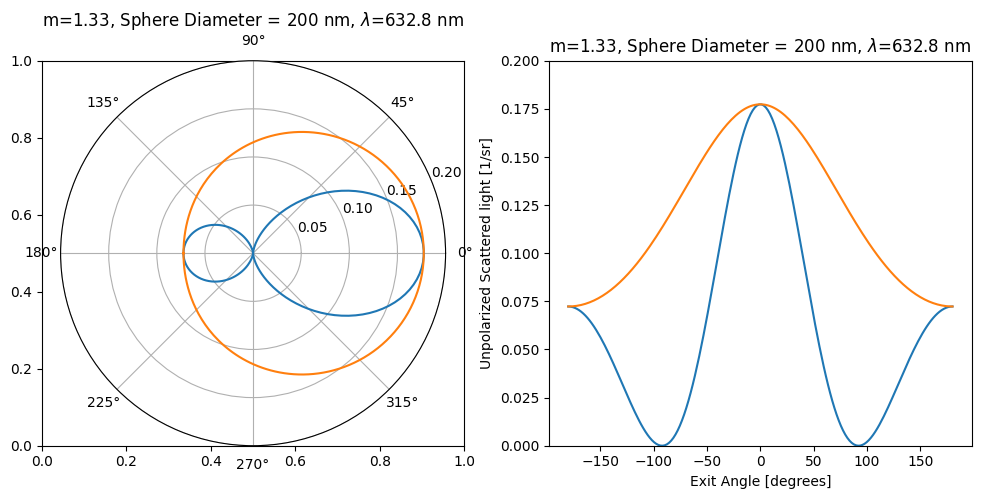

In [5]:
m = 1.33
lambda0 = 632.8 # nm
d = 200        # nm

theta = np.linspace(-180,180,180)
mu = np.cos(theta/180*np.pi)

Ipar, Iper = miepython.ez_intensities(m, d, lambda0, mu)

fig,ax = plt.subplots(1,2,figsize=(12,5))
ax=plt.subplot(121, projection='polar')
ax.plot(theta/180*np.pi,Ipar)
ax.plot(theta/180*np.pi,Iper)

ax.set_rticks([0.05, 0.1, 0.15, 0.20])
plt.title("m=%.2f, Sphere Diameter = %.0f nm, $\lambda$=%.1f nm" % (m, d, lambda0))

plt.subplot(122)
plt.plot(theta,Ipar)
plt.plot(theta,Iper)

plt.xlabel('Exit Angle [degrees]')
plt.ylabel('Unpolarized Scattered light [1/sr]')
plt.title("m=%.2f, Sphere Diameter = %.0f nm, $\lambda$=%.1f nm" % (m, d, lambda0))
plt.ylim(0.00,0.2)

plt.show()

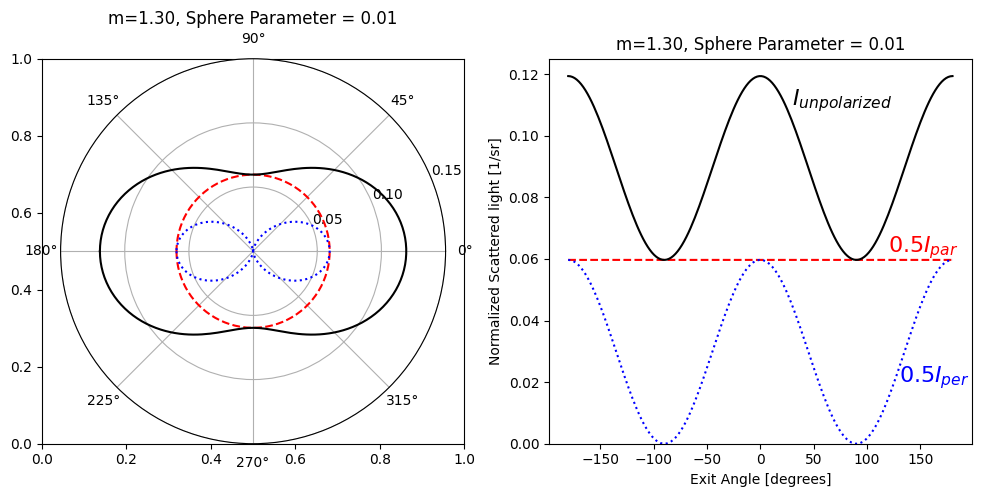

In [6]:
""" Rayleigh scattering """

m = 1.3
x = 0.01
theta = np.linspace(-180,180,180)
mu = np.cos(theta/180*np.pi)
ipar = miepython.i_par(m,x,mu)/2
iper = miepython.i_per(m,x,mu)/2
iun  = miepython.i_unpolarized(m,x,mu)

fig,ax = plt.subplots(1,2,figsize=(12,5))
ax=plt.subplot(121, projection='polar')
ax.plot(theta/180*np.pi,iper,'r--')
ax.plot(theta/180*np.pi,ipar,'b:')
ax.plot(theta/180*np.pi,iun,'k')

ax.set_rticks([0.05, 0.1,0.15])
plt.title('m=%.2f, Sphere Parameter = %.2f' %(m,x))

plt.subplot(122)
plt.plot(theta,iper,'r--')
plt.plot(theta,ipar,'b:')
plt.plot(theta,iun,'k')

plt.xlabel('Exit Angle [degrees]')
plt.ylabel('Normalized Scattered light [1/sr]')
plt.title('m=%.2f, Sphere Parameter = %.2f' %(m,x))
plt.ylim(0.00,0.125)
plt.text(130,0.02,r"$0.5I_{per}$",color="blue", fontsize=16)
plt.text(120,0.062,r"$0.5I_{par}$",color="red", fontsize=16)
plt.text(30,0.11,r"$I_{unpolarized}$",color="black", fontsize=16)


plt.show()

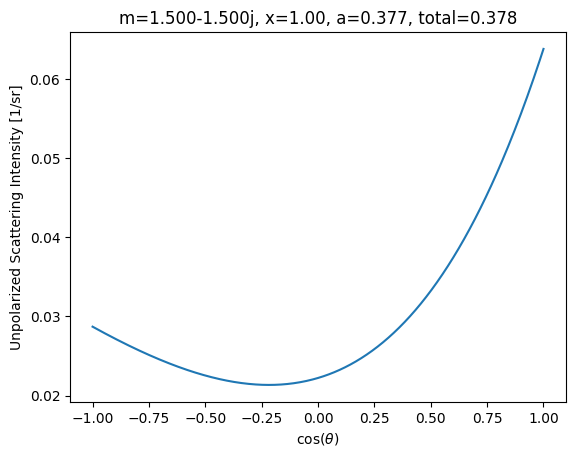

In [7]:
"""CASE 2: m = 1.5 - 1.5j, x = 1"""


m = 1.5 - 1.5j
x = 1
mu = np.linspace(-1,1,501)
intensity = miepython.i_unpolarized(m,x,mu)
qext, qsca, qback, g = miepython.mie(m,x)
a = qsca/qext

#integrate over all angles
dmu = mu[1] - mu[0]
total = 2 * np.pi * dmu * np.sum(intensity)

plt.plot(mu,intensity)
plt.xlabel(r'$\cos(\theta)$')
plt.ylabel('Unpolarized Scattering Intensity [1/sr]')
plt.title('m=%.3f%+.3fj, x=%.2f, a=%.3f, total=%.3f'%(m.real,m.imag,x,a, total))
plt.show()

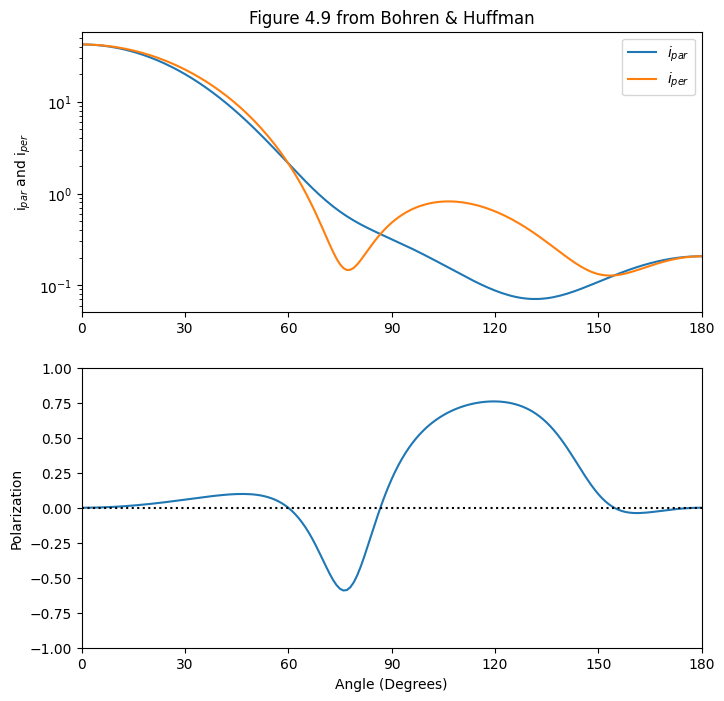

In [8]:
"""water dropplets"""

x=3
m=1.33-1e-8j

theta = np.linspace(0,180,181)
mu = np.cos(theta*np.pi/180)

scaling_factor = 16*np.pi # esto hace falta para que coincida con el del libro
iper = scaling_factor*miepython.i_per(m,x,mu)
ipar = scaling_factor*miepython.i_par(m,x,mu)

P = (iper-ipar)/(iper+ipar)

plt.subplots(2,1,figsize=(8,8))
plt.subplot(2,1,1)
plt.semilogy(theta,ipar,label='$i_{par}$')
plt.semilogy(theta,iper,label='$i_{per}$')
plt.xlim(0,180)
plt.xticks(range(0,181,30))
plt.ylabel('i$_{par}$ and i$_{per}$')
plt.legend()
plt.title('Figure 4.9 from Bohren & Huffman')
plt.subplot(2,1,2)
plt.plot(theta,P)
plt.ylim(-1,1)
plt.xticks(range(0,181,30))
plt.xlim(0,180)
plt.ylabel('Polarization')
plt.plot([0,180],[0,0],':k')
plt.xlabel('Angle (Degrees)')
plt.show()

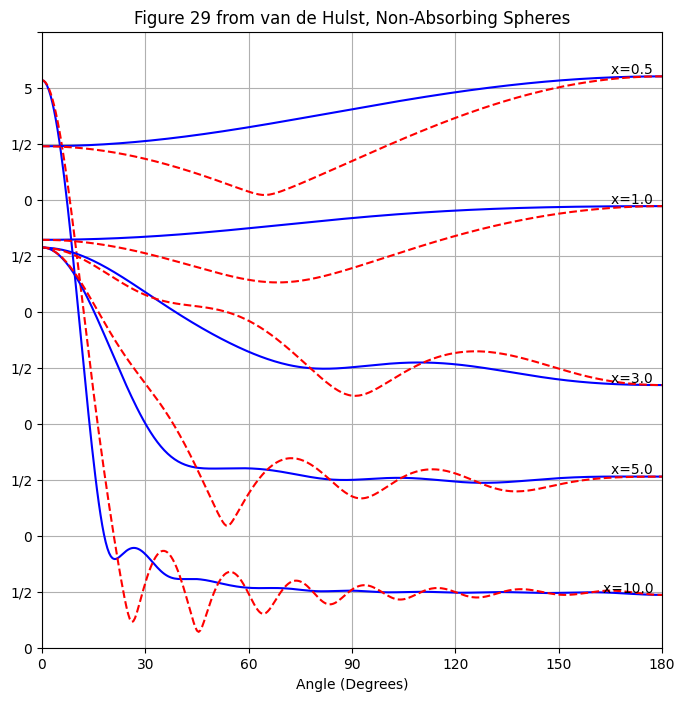

In [9]:
"""van de Hulst Comparison"""

x=5
m=10000

theta = np.linspace(0,180,361)
mu = np.cos(theta*np.pi/180)

fig, ax = plt.subplots(figsize=(8,8))

x=10
s1,s2 = miepython.mie_S1_S2(m,x,mu)
sone = 2.5*abs(s1)
stwo = 2.5*abs(s2)
plt.plot(theta,sone,'b')
plt.plot(theta,stwo,'--r')
plt.annotate('x=%.1f  '%x,xy=(theta[-1],sone[-1]),ha='right',va='bottom')

x=5
s1,s2 = miepython.mie_S1_S2(m,x,mu)
sone = 2.5*abs(s1) + 1
stwo = 2.5*abs(s2) + 1
plt.plot(theta,sone,'b')
plt.plot(theta,stwo,'--r')
plt.annotate('x=%.1f  '%x,xy=(theta[-1],sone[-1]),ha='right',va='bottom')

x=3
s1,s2 = miepython.mie_S1_S2(m,x,mu)
sone = 2.5*abs(s1) + 2
stwo = 2.5*abs(s2) + 2
plt.plot(theta,sone,'b')
plt.plot(theta,stwo,'--r')
plt.annotate('x=%.1f  '%x,xy=(theta[-1],sone[-1]),ha='right',va='bottom')

x=1
s1,s2 = miepython.mie_S1_S2(m,x,mu)
sone = 2.5*abs(s1) + 3
stwo = 2.5*abs(s2) + 3
plt.plot(theta,sone,'b')
plt.plot(theta,stwo,'--r')
plt.annotate('x=%.1f  '%x,xy=(theta[-1],sone[-1]),ha='right',va='bottom')

x=0.5
s1,s2 = miepython.mie_S1_S2(m,x,mu)
sone = 2.5*abs(s1) + 4
stwo = 2.5*abs(s2) + 4
plt.plot(theta,sone,'b')
plt.plot(theta,stwo,'--r')
plt.annotate('x=%.1f  '%x,xy=(theta[-1],sone[-1]),ha='right',va='bottom')

plt.xlim(0,180)
plt.ylim(0,5.5)
plt.xticks(range(0,181,30))
plt.yticks(np.arange(0,5.51,0.5))
plt.title('Figure 29 from van de Hulst, Non-Absorbing Spheres')
plt.xlabel('Angle (Degrees)')
ax.set_yticklabels(['0','1/2','0','1/2','0','1/2','0','1/2','0','1/2','5',' '])
plt.grid(True)
plt.show()

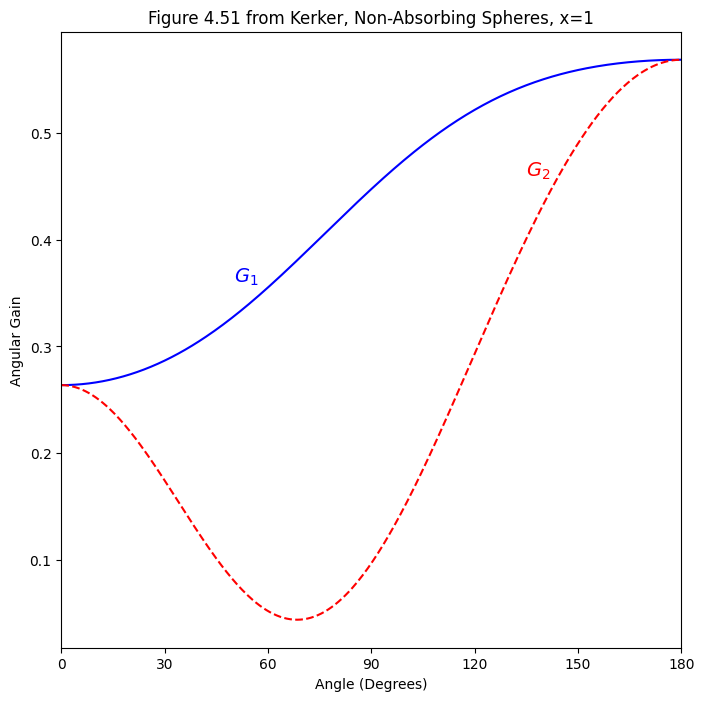

In [10]:
"""ANGULAR GAIN"""

## Kerker, Angular Gain

x=1
m=10000

theta = np.linspace(0,180,361)
mu = np.cos(theta*np.pi/180)

fig, ax = plt.subplots(figsize=(8,8))

s1,s2 = miepython.mie_S1_S2(m,x,mu)

G1 = 4*abs(s1)**2/x**2
G2 = 4*abs(s2)**2/x**2

plt.plot(theta,G1,'b')
plt.plot(theta,G2,'--r')
plt.annotate('$G_1$',xy=(50,0.36),color='blue',fontsize=14)
plt.annotate('$G_2$',xy=(135,0.46),color='red',fontsize=14)

plt.xlim(0,180)
plt.xticks(range(0,181,30))
plt.title('Figure 4.51 from Kerker, Non-Absorbing Spheres, x=1')
plt.xlabel('Angle (Degrees)')
plt.ylabel('Angular Gain')
plt.show()